<a href="https://colab.research.google.com/github/RaffayBaig/ANN-BreastCancerPrediction/blob/main/Potato_Leaf_Disease_Classification_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
!pip install opendatasets
import opendatasets as od
import tensorflow as tf
from tensorflow import keras


od.download("https://www.kaggle.com/datasets/arjuntejaswi/plant-village")



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: raffaybagi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/arjuntejaswi/plant-village


100%|██████████| 329M/329M [00:06<00:00, 56.6MB/s]


In [ ]:
!ls /content/plant-village/PlantVillage

Pepper__bell___Bacterial_spot  Tomato_Late_blight
Pepper__bell___healthy	       Tomato_Leaf_Mold
Potato___Early_blight	       Tomato_Septoria_leaf_spot
Potato___healthy	       Tomato_Spider_mites_Two_spotted_spider_mite
Potato___Late_blight	       Tomato__Target_Spot
Tomato_Bacterial_spot	       Tomato__Tomato_mosaic_virus
Tomato_Early_blight	       Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_healthy


In [ ]:
train_dataset = keras.utils.image_dataset_from_directory(
    directory='/content/plant-village/PlantVillage',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20638 files belonging to 15 classes.


In [ ]:
import os
import shutil

source = "/content/plant-village/PlantVillage"
target = "/content/potato_dataset"

os.makedirs(target, exist_ok=True)

classes = [
    "Potato___Early_blight",
    "Potato___healthy",
    "Potato___Late_blight"
]

for c in classes:
    shutil.copytree(
        os.path.join(source, c),
        os.path.join(target, c),
        dirs_exist_ok=True
    )

In [ ]:
!ls /content/potato_dataset

Potato___Early_blight  Potato___healthy  Potato___Late_blight


In [ ]:
IMAGE_SIZE=256
BATCH_SIZE=32
CHANNELS=3
EPOCHS=50

In [ ]:

df = tf.keras. preprocessing. image_dataset_from_directory(
"potato_dataset",
shuffle=True,
image_size = (IMAGE_SIZE, IMAGE_SIZE),
batch_size = BATCH_SIZE

)

Found 2152 files belonging to 3 classes.


In [ ]:
class_name=df.class_names
class_name

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [ ]:
len(df)

68

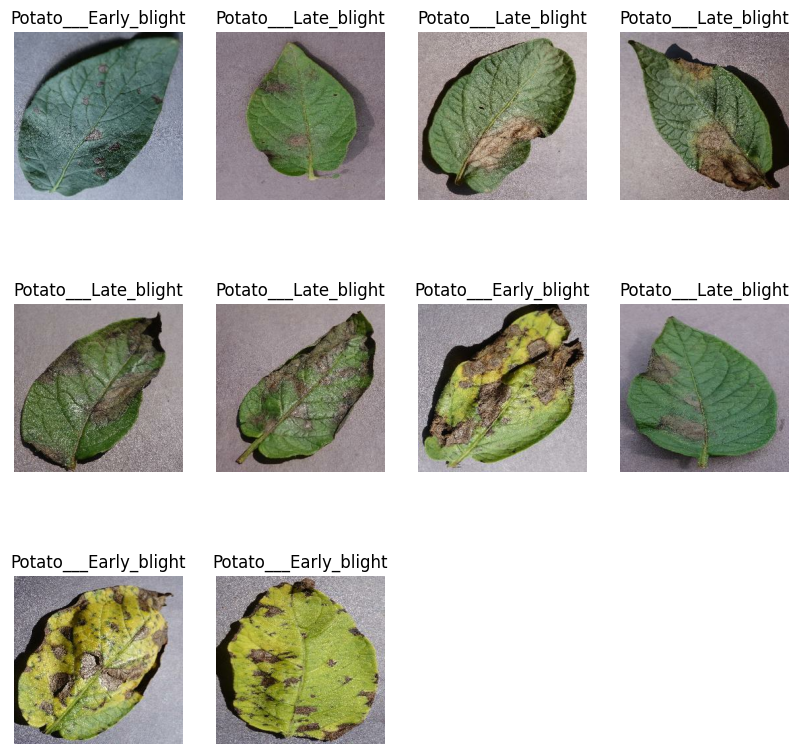

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for image_batch, label_batch in df.take(1):
 for i in range (10):
  ax=plt.subplot(3,4,i+1)
  plt.imshow(image_batch[i].numpy().astype("uint8"))
  plt.title(class_name[label_batch[i]])
  plt.axis("off")

In [ ]:
train_size=0.8
len(df)*train_size

54.400000000000006

In [ ]:
train_ds=df.take(54)
#54 batches

In [ ]:
test_ds=df.skip(54)
len(test_ds)

14

In [ ]:
val_size=len(test_ds)*0.1

val_ds=test_ds.take(6)
len(val_ds)

6

In [ ]:
test_ds=test_ds.skip(6)
len(test_ds)

8

In [ ]:
def get_datasets_partition(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=10000):
  ds_size=len(ds)
  if shuffle:
    ds=ds.shuffle(shuffle_size,seed=12
                  )
  train_size=int(train_split * ds_size)
  val_size = int(val_split * ds_size)

  train_ds=ds.take(train_size)
  val_ds=ds.skip(train_size).take(val_size)
  test_ds=ds.skip(train_size).skip(val_size)
  return train_ds,val_ds,test_ds


In [ ]:
train_ds, val_ds, test_ds = get_datasets_partition(df)

In [ ]:
len(train_ds)

54

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Input
from keras.models import Sequential
#preprocessign iamge

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(256, 256),#used where image size is diff
    layers.Rescaling(1./255) #rescaling iamge
])

data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("Horizontal_and_Vertical"),
    layers.RandomRotation(0.2)
    ])

In [ ]:
n_classes=3
input_shape=(BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3


n_classes = 3

model = Sequential()
model.add(Input(shape=(256,256,3)))

model.add(resize_and_rescale)
model.add(data_augmentation)

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64,activation='relu'))

model.add(Dense(n_classes,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_33 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_34 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_90 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_91 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_92 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_93 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_94 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_95 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_ds,validation_data=val_ds,epochs=EPOCHS,batch_size=BATCH_SIZE,verbose=1)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.4208 - loss: 0.9741 - val_accuracy: 0.4688 - val_loss: 0.9076
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.5812 - loss: 0.8555 - val_accuracy: 0.6458 - val_loss: 0.7085
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.7542 - loss: 0.5770 - val_accuracy: 0.7448 - val_loss: 0.5536
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8303 - loss: 0.4222 - val_accuracy: 0.8281 - val_loss: 0.4136
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8661 - loss: 0.3111 - val_accuracy: 0.8490 - val_loss: 0.3619
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8769 - loss: 0.3142 - val_accuracy: 0.8542 - val_loss: 0.3777
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9010 - loss: 0.2685 - val_accuracy: 0.8750 - val_loss: 0.3055
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9270 - loss: 0.1816 - val_accuracy: 0.9115 -

In [ ]:
model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9991 - loss: 0.0112


[0.03638439625501633, 0.99609375]

In [ ]:
accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

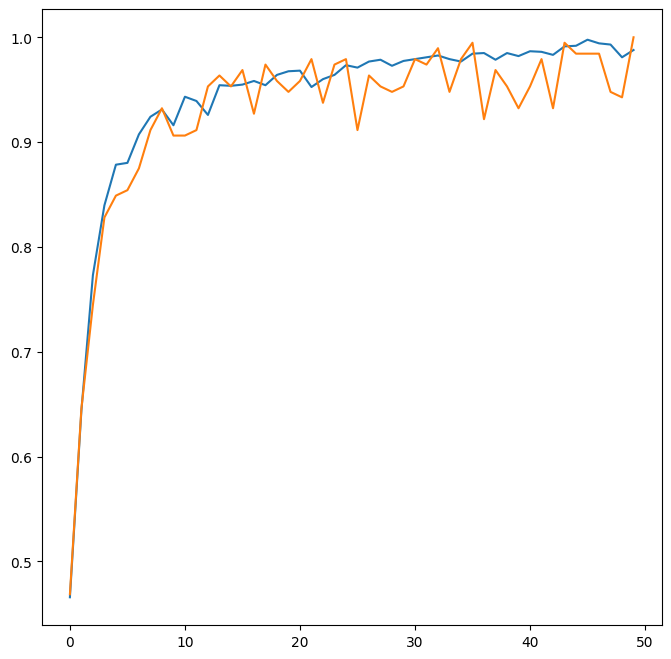

In [ ]:
plt.figure(figsize=(8,8))
plt.plot(range(EPOCHS),accuracy,label='Trainingaccuracy')
plt.plot(range(EPOCHS),val_accuracy,label='Validationaccuracy')

first image prediction
Image's actual label is : Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Image's predicted label Potato___Early_blight


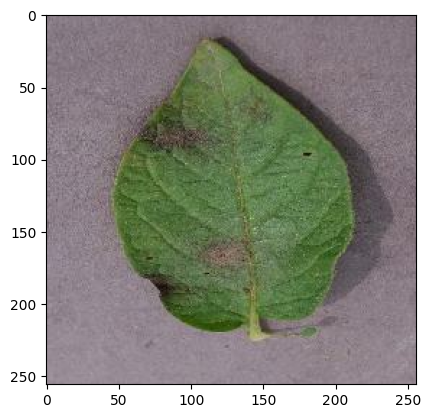

In [ ]:
for images_batch,labels_batch in test_ds.take(1):
  first_image=image_batch[1].numpy().astype('uint8')
  first_label=labels_batch[1].numpy()
  print("first image prediction")
  plt.imshow(first_image)
  print("Image's actual label is :",class_name[first_label])

  batch_prediction=model.predict(images_batch)
  print("Image's predicted label",class_name[np.argmax(batch_prediction[1])])


In [ ]:
import numpy as np

In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_name[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


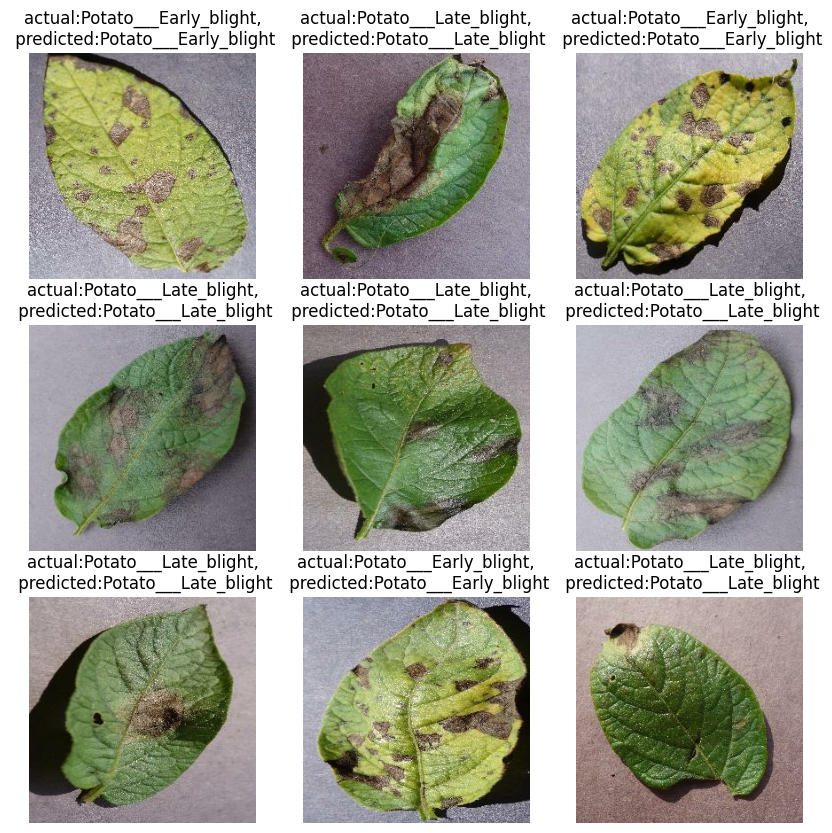

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
 for i in range(9):
  ax = plt.subplot(3, 3, i +1)
  plt.imshow(images[i].numpy().astype("uint8"))

  predicted_class,confidence=predict(model,images[i].numpy())
  actual_class=class_name[labels[i]]
  plt.title(f"actual:{actual_class},\n predicted:{predicted_class}")
  plt.axis("off")

In [ ]:
import os

model_version = 1

# create folder
os.makedirs("models", exist_ok=True)

# save model
model.save(f"models/{model_version}.keras")